In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from torch.utils.data import WeightedRandomSampler
import seaborn as sns
from sklearn.metrics import confusion_matrix
from PIL import Image
import os
import time
import random
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from skimage.io import imread

/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
classes = { 0:'Speed limit (20km/h)',
            1:'Speed limit (30km/h)', 
            2:'Speed limit (50km/h)', 
            3:'Speed limit (60km/h)', 
            4:'Speed limit (70km/h)', 
            5:'Speed limit (80km/h)', 
            6:'End of speed limit (80km/h)', 
            7:'Speed limit (100km/h)', 
            8:'Speed limit (120km/h)', 
            9:'No passing', 
            10:'No passing veh over 3.5 tons', 
            11:'Right-of-way at intersection', 
            12:'Priority road', 
            13:'Yield', 
            14:'Stop', 
            15:'No vehicles', 
            16:'Veh > 3.5 tons prohibited', 
            17:'No entry', 
            18:'General caution', 
            19:'Dangerous curve left', 
            20:'Dangerous curve right', 
            21:'Double curve', 
            22:'Bumpy road', 
            23:'Slippery road', 
            24:'Road narrows on the right', 
            25:'Road work', 
            26:'Traffic signals', 
            27:'Pedestrians', 
            28:'Children crossing', 
            29:'Bicycles crossing', 
            30:'Beware of ice/snow',
            31:'Wild animals crossing', 
            32:'End speed + passing limits', 
            33:'Turn right ahead', 
            34:'Turn left ahead', 
            35:'Ahead only', 
            36:'Go straight or right', 
            37:'Go straight or left', 
            38:'Keep right', 
            39:'Keep left', 
            40:'Roundabout mandatory', 
            41:'End of no passing', 
            42:'End no passing veh > 3.5 tons' }

In [5]:
random.seed(42)
np.random.seed(42)
os.environ["PYTHONHASHSEED"] = str(42)
    
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.cuda.manual_seed_all(42)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [6]:
data_dir = './data'
train_path = './data/Train'
test_path = './data'

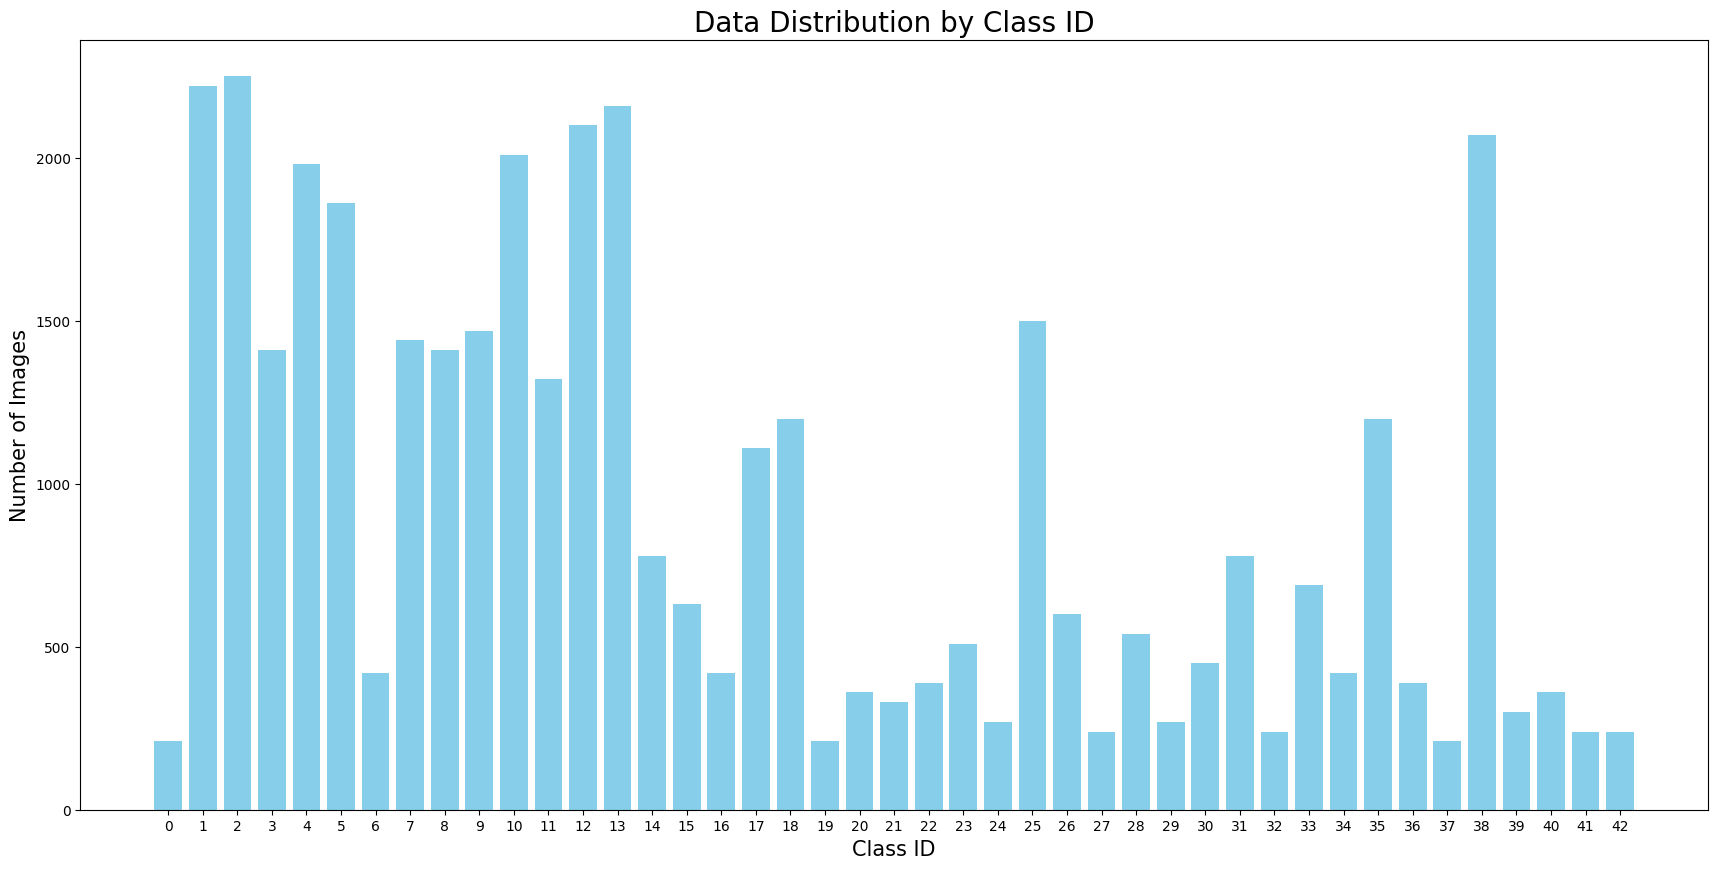

In [7]:
folders = sorted(os.listdir(train_path), key=lambda x: int(x))

train_number = []
class_num = []

for folder in folders:
    train_files = os.listdir(os.path.join(train_path, folder))
    train_number.append(len(train_files))
    class_num.append(int(folder)) 

plt.figure(figsize=(21,10))  
plt.bar(class_num, train_number, color='skyblue')
plt.xticks(class_num)
plt.xlabel('Class ID', fontsize=15)
plt.ylabel('Number of Images', fontsize=15)
plt.title('Data Distribution by Class ID', fontsize=20)
plt.show()

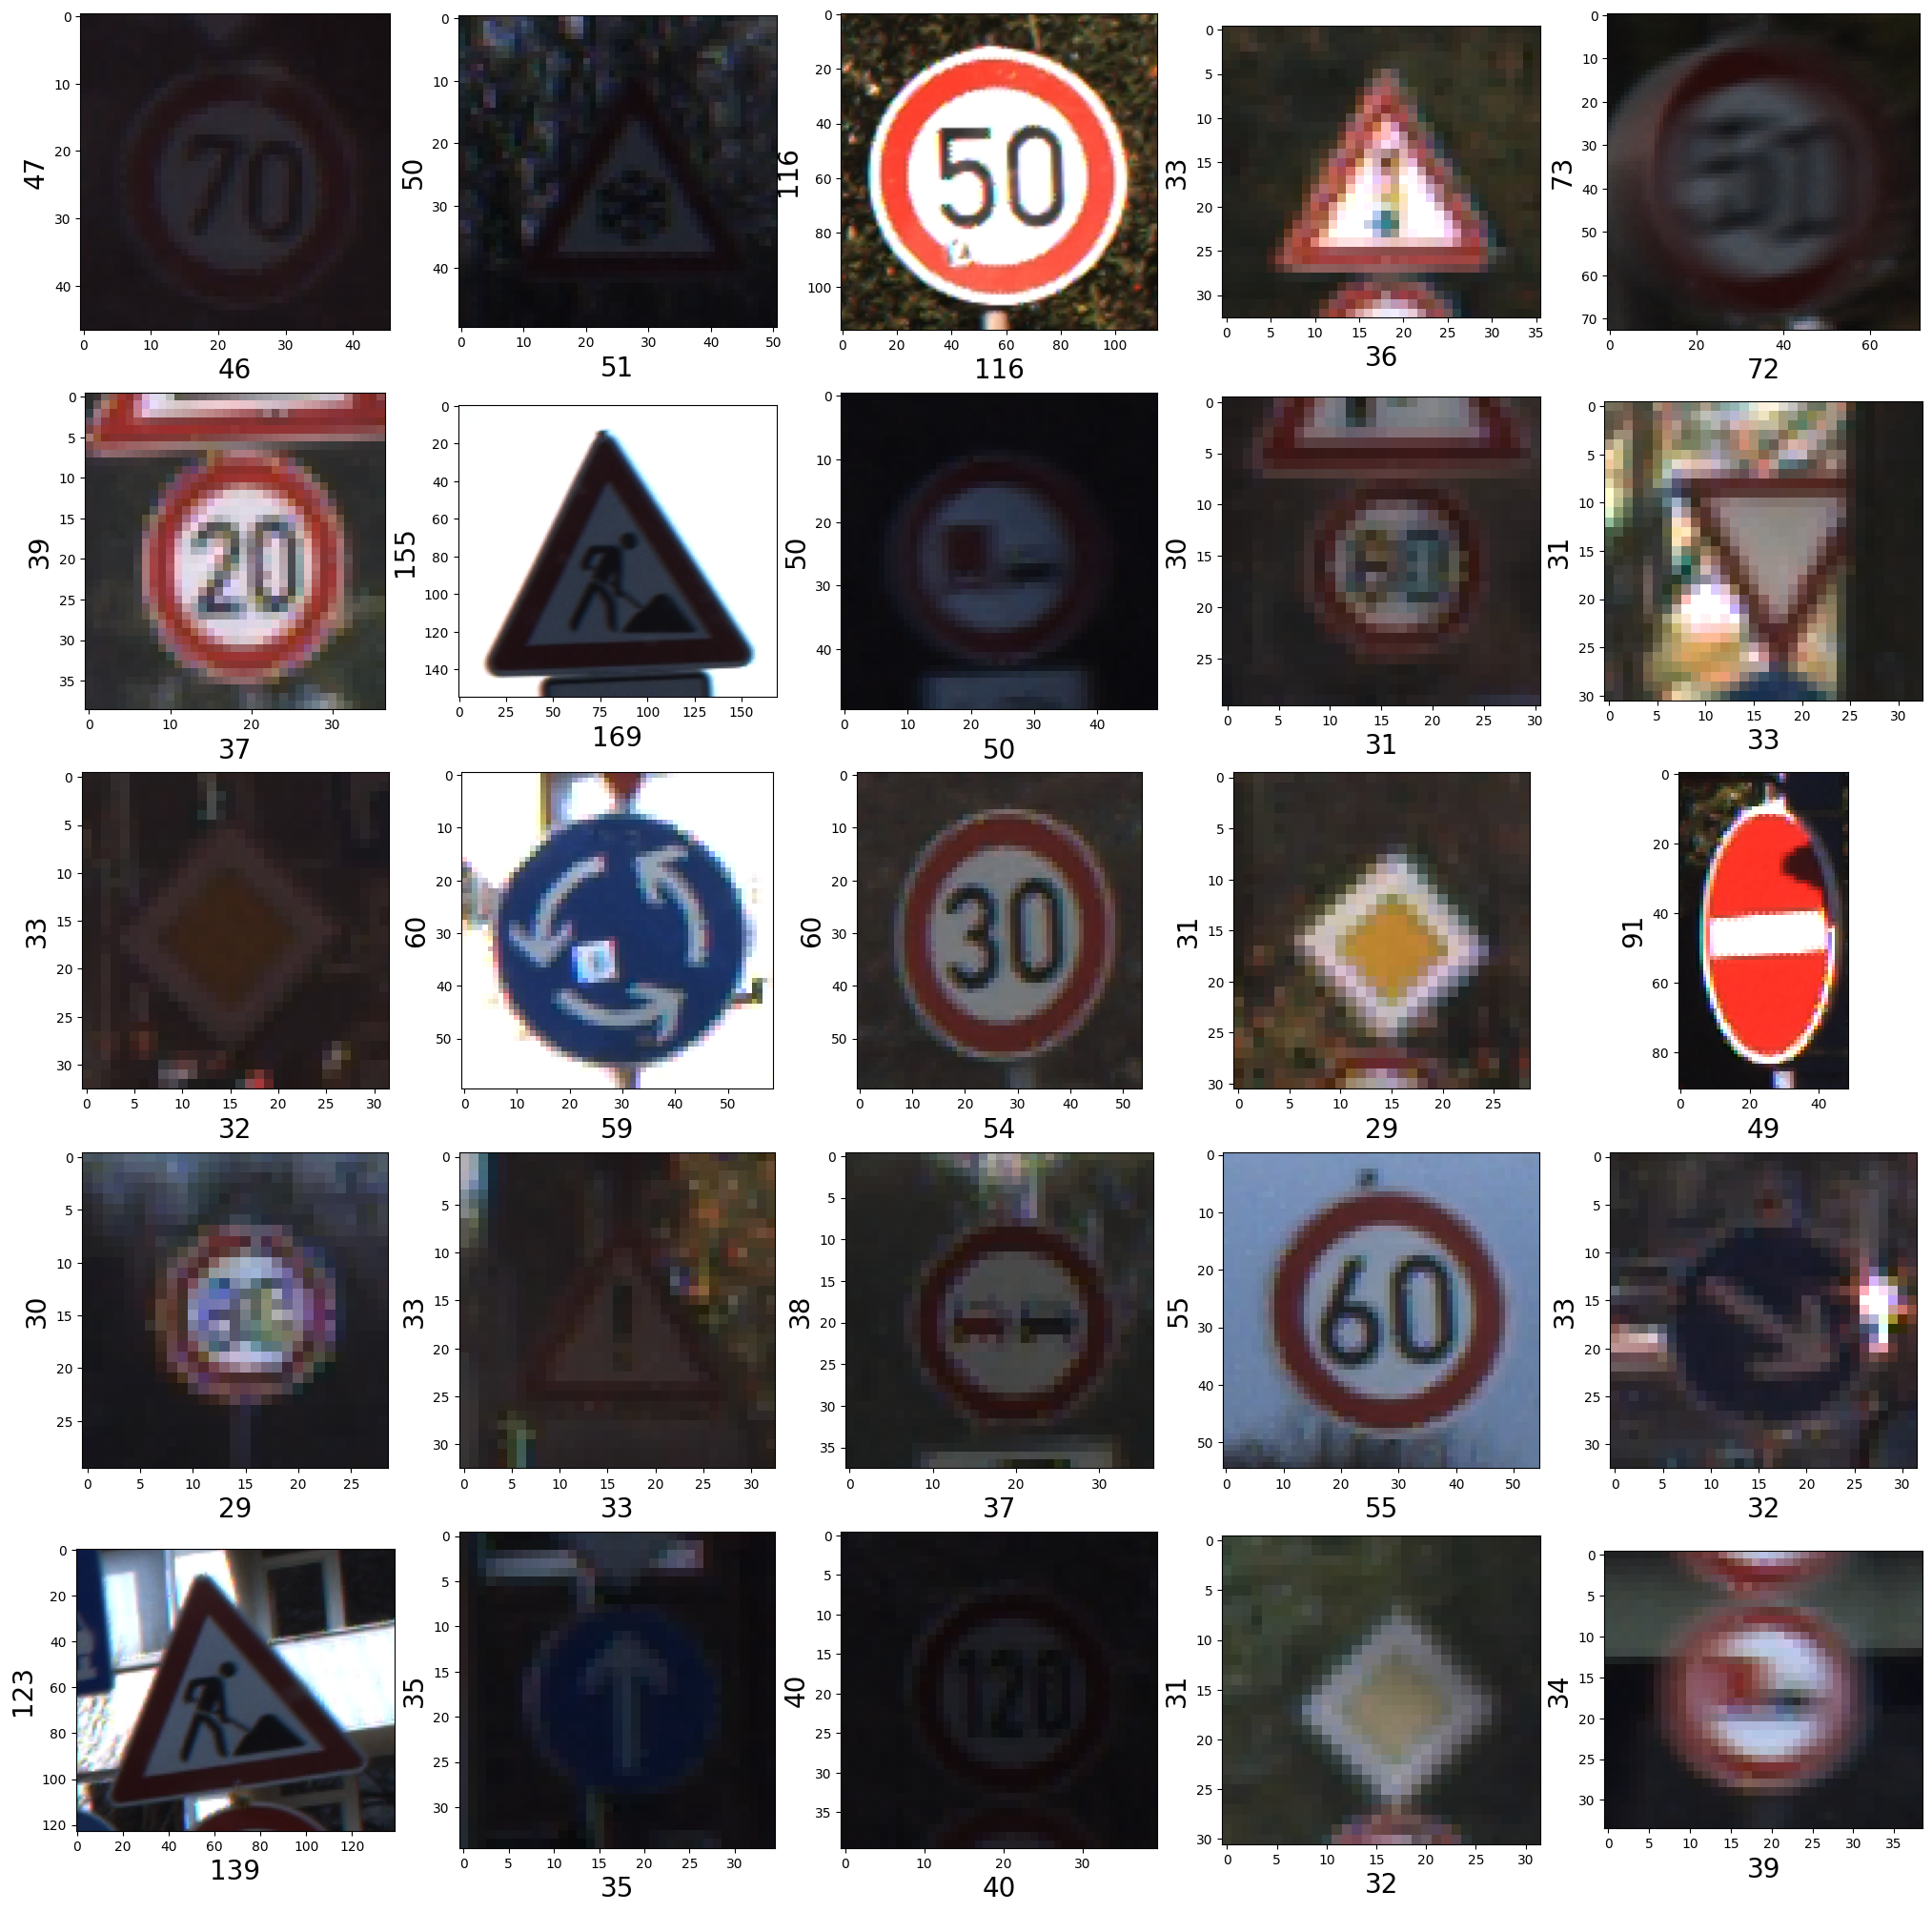

In [8]:
test = pd.read_csv(data_dir + '/Test.csv')
imgs = test["Path"].values

plt.figure(figsize=(25,25))

for i in range(1, 26):
    plt.subplot(5, 5, i)
    random_img_path = data_dir + '/' + random.choice(imgs)
    rand_img = imread(random_img_path)
    plt.imshow(rand_img)
    
    plt.grid(False) 
    plt.xlabel(rand_img.shape[1], fontsize=20)
    plt.ylabel(rand_img.shape[0], fontsize=20)

In [9]:
class GTSRBDataset(Dataset):
    def __init__(self, root_dir, transform=None, is_train=True):
        self.root_dir = root_dir
        self.transform = transform
        self.is_train = is_train

        if self.is_train:
            self.samples = []
            for class_id in os.listdir(root_dir):
                class_path = os.path.join(root_dir, class_id)
                if os.path.isdir(class_path):
                    for img_name in os.listdir(class_path):
                        if img_name.endswith('.png'):
                            self.samples.append((os.path.join(class_path, img_name), int(class_id)))
        else:
            csv_path = os.path.join(root_dir, 'Test.csv')
            self.csv_data = pd.read_csv(csv_path)

    def __len__(self):
        return len(self.samples) if self.is_train else len(self.csv_data)

    def __getitem__(self, idx):
        if self.is_train:
            img_path, label = self.samples[idx]
        else:
            row = self.csv_data.iloc[idx]
            img_path = os.path.join(self.root_dir, row['Path']) 
            label = int(row['ClassId'])
            
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        return image, label

In [10]:
# NaiveCNN용 (30x30)
transform_30 = transforms.Compose([
    transforms.Resize((30, 30)),
    transforms.ToTensor(),
])

# 최적화 모델용 (48x48)
transform_48 = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
])

train_ds_30 = GTSRBDataset(root_dir=train_path, transform=transform_30, is_train=True)
test_ds_30 = GTSRBDataset(root_dir=test_path, transform=transform_30, is_train=False)

train_loader_30 = DataLoader(train_ds_30, batch_size=64, shuffle=True)
test_loader_30 = DataLoader(test_ds_30, batch_size=64, shuffle=False)

train_ds_48 = GTSRBDataset(root_dir=train_path, transform=transform_48, is_train=True)
test_ds_48 = GTSRBDataset(root_dir=test_path, transform=transform_48, is_train=False)

train_loader_48 = DataLoader(train_ds_48, batch_size=64, shuffle=True)
test_loader_48 = DataLoader(test_ds_48, batch_size=64, shuffle=False)

In [11]:
class NaiveCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=5) 
        self.conv2 = nn.Conv2d(32, 64, kernel_size=5)
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3)
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        # 30x30 입력 시 Flatten 크기: 256 * 3 * 3 = 2304
        self.fc1 = nn.Linear(2304, 512)
        self.fc2 = nn.Linear(512, 43)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool1(x)

        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool2(x)

        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [12]:
class GAPOnlyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=5), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3), nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=3), nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Global Average Pooling: (Batch, 256, H, W) -> (Batch, 256, 1, 1)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Linear(256, 512)
        self.fc2 = nn.Linear(512, 43)

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [13]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, padding=0):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=kernel_size, 
                                   padding=padding, groups=in_channels, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels)
        
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        x = F.relu(self.bn1(self.depthwise(x)))
        x = F.relu(self.bn2(self.pointwise(x)))
        return x

class DSConvCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # 모든 Conv2d를 DepthwiseSeparableConv로 대체
        self.conv1 = DepthwiseSeparableConv(3, 32, kernel_size=5)
        self.conv2 = DepthwiseSeparableConv(32, 64, kernel_size=5)
        self.pool1 = nn.MaxPool2d(2)

        self.conv3 = DepthwiseSeparableConv(64, 128, kernel_size=3)
        self.conv4 = DepthwiseSeparableConv(128, 256, kernel_size=3)
        self.pool2 = nn.MaxPool2d(2)

        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Linear(256, 512)
        self.fc2 = nn.Linear(512, 43)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.pool1(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.pool2(x)

        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [14]:
def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs, model_name, print_every=50):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    os.makedirs('./models', exist_ok=True)
    
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': [], 'time': []}
    best_val_acc = 0.0
    total_start_time = time.time()

    for epoch in range(num_epochs):
        epoch_start_time = time.time()
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        
        print(f"\n--- [{model_name}] Epoch {epoch+1}/{num_epochs} Start ---")
        
        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()
            
            if (batch_idx + 1) % print_every == 0:
                avg_loss = train_loss / (batch_idx + 1)
                acc = 100. * train_correct / train_total
                print(f"Batch [{batch_idx+1}/{len(train_loader)}] | Loss: {avg_loss:.4f} | Acc: {acc:.2f}%")

        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        # 통계
        epoch_duration = time.time() - epoch_start_time
        curr_val_acc = val_correct / val_total
        
        history['loss'].append(train_loss / len(train_loader))
        history['accuracy'].append(train_correct / train_total)
        history['val_loss'].append(val_loss / len(test_loader))
        history['val_accuracy'].append(curr_val_acc)
        history['time'].append(epoch_duration)

        print(f"Result -> Loss: {history['loss'][-1]:.4f} | Acc: {history['accuracy'][-1]*100:.2f}% | "
              f"Val_Loss: {history['val_loss'][-1]:.4f} | Val_Acc: {curr_val_acc*100:.2f}% | Time: {epoch_duration:.2f}s")

        if curr_val_acc > best_val_acc:
            best_val_acc = curr_val_acc
            torch.save(model.state_dict(), f'./models/best_{model_name}.pth')
            print(f"New Best Model Saved: {model_name}")

    return history

In [15]:
criterion = nn.CrossEntropyLoss()
model_naive = NaiveCNN()
optimizer_naive = optim.Adam(model_naive.parameters(), lr=0.001)

history_naive = train_model(
    model_naive, train_loader_30, test_loader_30, 
    criterion, optimizer_naive, num_epochs=10, 
    model_name="NaiveCNN", 
    print_every=100
)


--- [NaiveCNN] Epoch 1/10 Start ---
Batch [100/613] | Loss: 3.2442 | Acc: 13.36%
Batch [200/613] | Loss: 2.4532 | Acc: 30.64%
Batch [300/613] | Loss: 1.8720 | Acc: 46.40%
Batch [400/613] | Loss: 1.4922 | Acc: 57.08%
Batch [500/613] | Loss: 1.2412 | Acc: 64.32%
Batch [600/613] | Loss: 1.0619 | Acc: 69.46%
Result -> Loss: 1.0425 | Acc: 70.00% | Val_Loss: 0.3944 | Val_Acc: 90.15% | Time: 14.46s
New Best Model Saved: NaiveCNN

--- [NaiveCNN] Epoch 2/10 Start ---
Batch [100/613] | Loss: 0.1047 | Acc: 96.94%
Batch [200/613] | Loss: 0.0974 | Acc: 97.16%
Batch [300/613] | Loss: 0.0907 | Acc: 97.31%
Batch [400/613] | Loss: 0.0886 | Acc: 97.35%
Batch [500/613] | Loss: 0.0856 | Acc: 97.49%
Batch [600/613] | Loss: 0.0812 | Acc: 97.63%
Result -> Loss: 0.0799 | Acc: 97.67% | Val_Loss: 0.2781 | Val_Acc: 94.18% | Time: 13.06s
New Best Model Saved: NaiveCNN

--- [NaiveCNN] Epoch 3/10 Start ---
Batch [100/613] | Loss: 0.0432 | Acc: 98.83%
Batch [200/613] | Loss: 0.0458 | Acc: 98.71%
Batch [300/613] | L

In [16]:
model_gap = GAPOnlyCNN()
optimizer_gap = optim.Adam(model_gap.parameters(), lr=0.001)

history_gap = train_model(
    model_gap, train_loader_48, test_loader_48,
    criterion, optimizer_gap, num_epochs=10, 
    model_name="GAPOnlyCNN", 
    print_every=100
)


--- [GAPOnlyCNN] Epoch 1/10 Start ---
Batch [100/613] | Loss: 3.4872 | Acc: 6.73%
Batch [200/613] | Loss: 3.3614 | Acc: 9.01%
Batch [300/613] | Loss: 3.2130 | Acc: 11.40%
Batch [400/613] | Loss: 3.1053 | Acc: 13.27%
Batch [500/613] | Loss: 2.9985 | Acc: 15.26%
Batch [600/613] | Loss: 2.8726 | Acc: 17.64%
Result -> Loss: 2.8561 | Acc: 17.97% | Val_Loss: 2.1825 | Val_Acc: 32.84% | Time: 15.54s
New Best Model Saved: GAPOnlyCNN

--- [GAPOnlyCNN] Epoch 2/10 Start ---
Batch [100/613] | Loss: 1.9900 | Acc: 36.11%
Batch [200/613] | Loss: 1.9256 | Acc: 37.59%
Batch [300/613] | Loss: 1.8275 | Acc: 40.32%
Batch [400/613] | Loss: 1.7478 | Acc: 42.47%
Batch [500/613] | Loss: 1.6787 | Acc: 44.39%
Batch [600/613] | Loss: 1.5933 | Acc: 46.92%
Result -> Loss: 1.5821 | Acc: 47.27% | Val_Loss: 1.2725 | Val_Acc: 58.40% | Time: 15.28s
New Best Model Saved: GAPOnlyCNN

--- [GAPOnlyCNN] Epoch 3/10 Start ---
Batch [100/613] | Loss: 0.9893 | Acc: 66.08%
Batch [200/613] | Loss: 0.9440 | Acc: 67.85%
Batch [300/

In [17]:
model_ds = DSConvCNN()
optimizer_ds = optim.Adam(model_ds.parameters(), lr=0.001)

history_ds = train_model(
    model_ds, train_loader_48, test_loader_48,
    criterion, optimizer_ds, num_epochs=10, 
    model_name="DSConvCNN", 
    print_every=100
)


--- [DSConvCNN] Epoch 1/10 Start ---
Batch [100/613] | Loss: 3.1742 | Acc: 13.12%
Batch [200/613] | Loss: 2.7514 | Acc: 21.87%
Batch [300/613] | Loss: 2.4220 | Acc: 28.98%
Batch [400/613] | Loss: 2.1884 | Acc: 34.62%
Batch [500/613] | Loss: 2.0051 | Acc: 39.28%
Batch [600/613] | Loss: 1.8486 | Acc: 43.53%
Result -> Loss: 1.8295 | Acc: 44.06% | Val_Loss: 1.2154 | Val_Acc: 62.05% | Time: 16.32s
New Best Model Saved: DSConvCNN

--- [DSConvCNN] Epoch 2/10 Start ---
Batch [100/613] | Loss: 0.8895 | Acc: 71.27%
Batch [200/613] | Loss: 0.8468 | Acc: 72.49%
Batch [300/613] | Loss: 0.7864 | Acc: 74.39%
Batch [400/613] | Loss: 0.7472 | Acc: 75.59%
Batch [500/613] | Loss: 0.7048 | Acc: 77.01%
Batch [600/613] | Loss: 0.6598 | Acc: 78.48%
Result -> Loss: 0.6551 | Acc: 78.64% | Val_Loss: 0.6938 | Val_Acc: 79.68% | Time: 14.83s
New Best Model Saved: DSConvCNN

--- [DSConvCNN] Epoch 3/10 Start ---
Batch [100/613] | Loss: 0.3820 | Acc: 87.86%
Batch [200/613] | Loss: 0.3686 | Acc: 88.44%
Batch [300/613

In [18]:
def print_parameters(model, model_name, verbose=True):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    if verbose:
        print(f"\n{'='*20} [{model_name} Layer Details] {'='*20}")
        print(f"{'Layer Name':<40} | {'Shape':<25} | {'Parameters':<15}")
        print("-" * 85)
        
        for name, param in model.named_parameters():
            if param.requires_grad:
                num = param.numel()
                shape_str = str(list(param.shape))
                print(f"{name:<40} | {shape_str:<25} | {num:>15,}")
        
        print("-" * 85)
        print(f"{'TOTAL TRAINABLE PARAMETERS':<68} | {total_params:>15,}")
        print('='*85)
    else:
        print(f"[{model_name}] Total Trainable Params: {total_params:,}")
    
    return total_params

In [19]:
print_parameters(model_naive, "NaiveCNN", verbose=True)
print_parameters(model_gap, "GAPOnlyCNN", verbose=True)
print_parameters(model_ds, "DSConvCNN", verbose=True)


==================== [NaiveCNN Layer Details] ====================
Layer Name                               | Shape                     | Parameters     
-------------------------------------------------------------------------------------
conv1.weight                             | [32, 3, 5, 5]             |           2,400
conv1.bias                               | [32]                      |              32
conv2.weight                             | [64, 32, 5, 5]            |          51,200
conv2.bias                               | [64]                      |              64
conv3.weight                             | [128, 64, 3, 3]           |          73,728
conv3.bias                               | [128]                     |             128
conv4.weight                             | [256, 128, 3, 3]          |         294,912
conv4.bias                               | [256]                     |             256
fc1.weight                               | [512, 2304]         

200764

In [20]:
print_parameters(model_naive, "NaiveCNN", verbose=False)
print_parameters(model_gap, "GAPOnlyCNN", verbose=False)
print_parameters(model_ds, "DSConvCNN", verbose=False)

[NaiveCNN] Total Trainable Params: 1,624,939
[GAPOnlyCNN] Total Trainable Params: 576,363
[DSConvCNN] Total Trainable Params: 200,764


200764

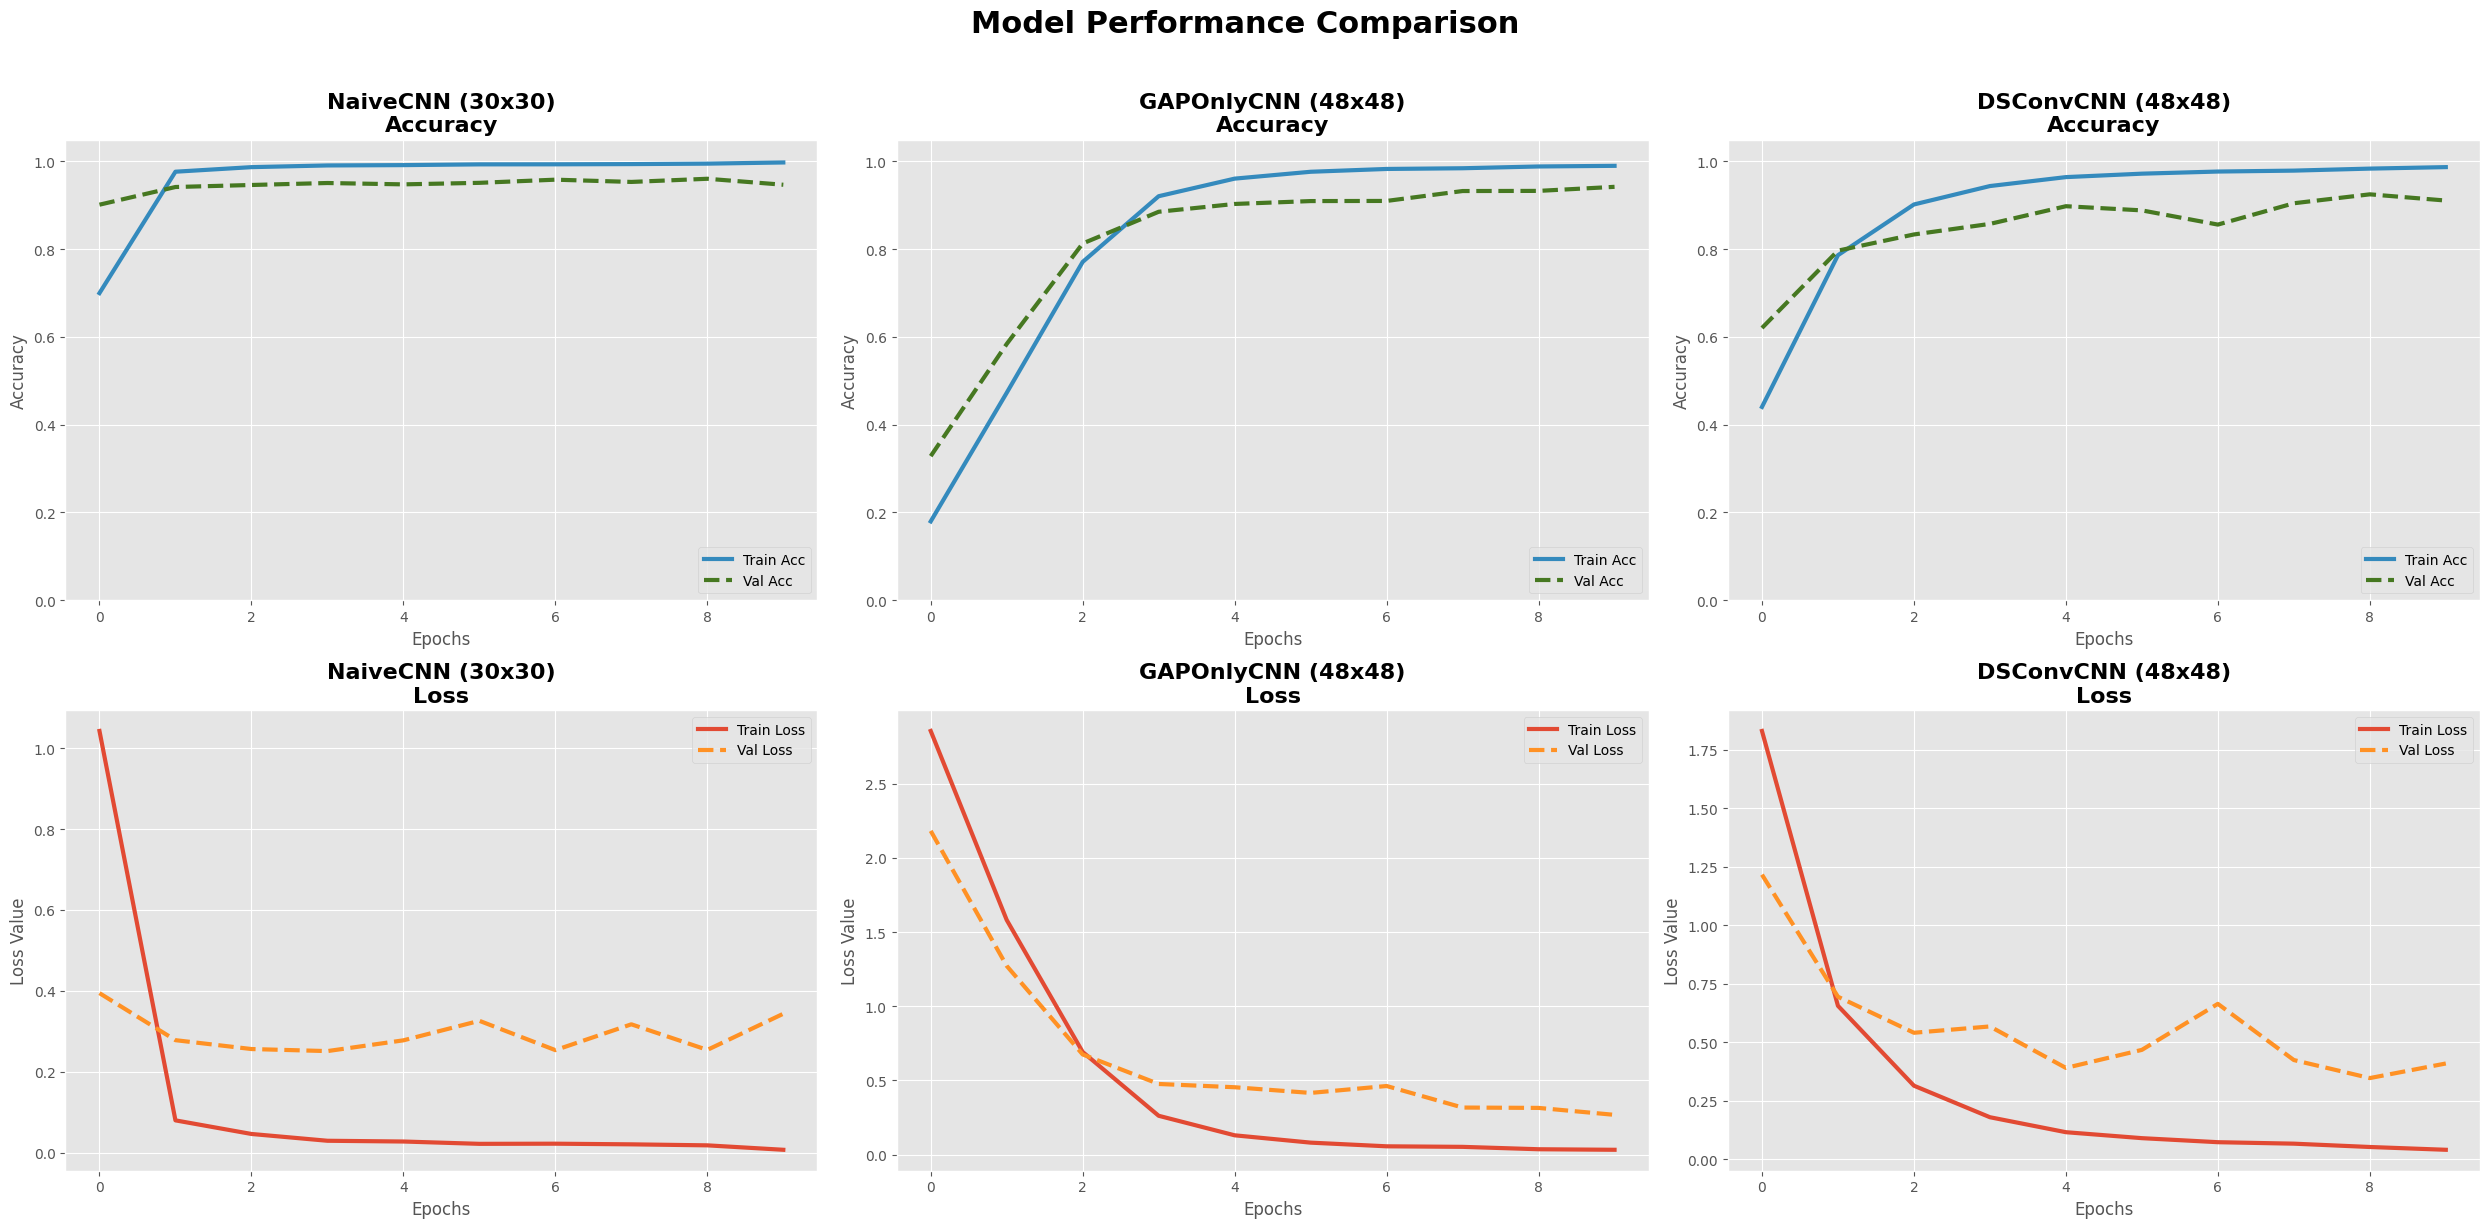

In [21]:
plt.style.use('ggplot')
fig, axes = plt.subplots(2, 3, figsize=(25, 12))

histories = [history_naive, history_gap, history_ds]
model_names = ["NaiveCNN (30x30)", "GAPOnlyCNN (48x48)", "DSConvCNN (48x48)"]

for i, (hist, name) in enumerate(zip(histories, model_names)):
    ax_acc = axes[0, i]
    ax_acc.plot(hist['accuracy'], label='Train Acc', color='#348ABD', linewidth=3)
    ax_acc.plot(hist['val_accuracy'], label='Val Acc', color='#467821', linewidth=3, linestyle='--')
    
    ax_acc.set_title(f'{name}\nAccuracy', fontsize=16, fontweight='bold')
    ax_acc.set_xlabel('Epochs')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.set_ylim(0, 1.05) 
    ax_acc.legend(loc='lower right')
    ax_acc.grid(True)

    ax_loss = axes[1, i]
    ax_loss.plot(hist['loss'], label='Train Loss', color='#E24A33', linewidth=3)
    ax_loss.plot(hist['val_loss'], label='Val Loss', color='#FF9124', linewidth=3, linestyle='--')
    
    ax_loss.set_title(f'{name}\nLoss', fontsize=16, fontweight='bold')
    ax_loss.set_xlabel('Epochs')
    ax_loss.set_ylabel('Loss Value')
    ax_loss.legend(loc='upper right')
    ax_loss.grid(True)

plt.suptitle('Model Performance Comparison', fontsize=22, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

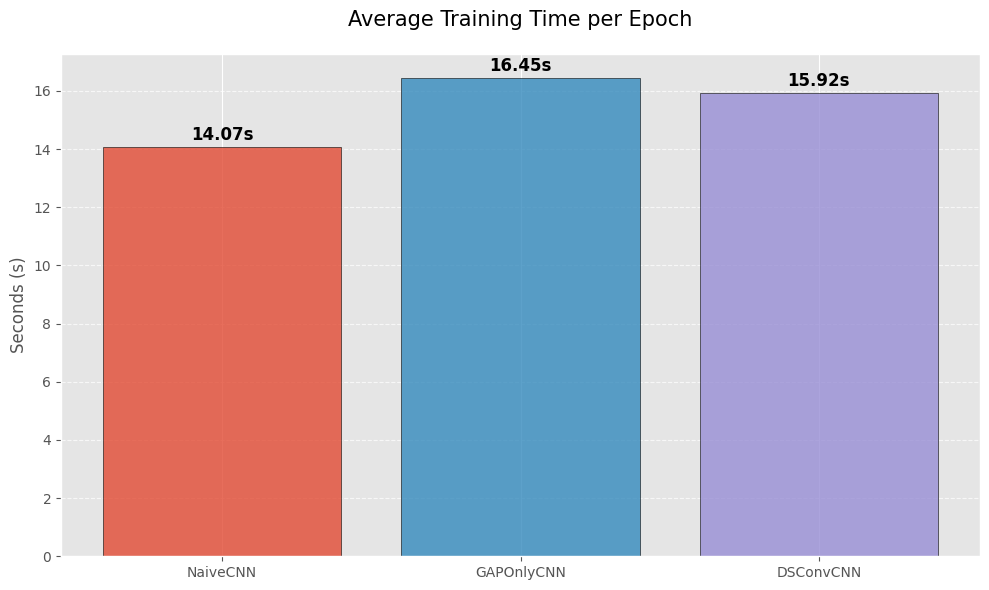

In [22]:
avg_times = [
    np.mean(history_naive['time']),
    np.mean(history_gap['time']),
    np.mean(history_ds['time'])
]

model_names = ["NaiveCNN", "GAPOnlyCNN", "DSConvCNN"]
colors = ['#E24A33', '#348ABD', '#988ED5']

plt.figure(figsize=(10, 6))
plt.style.use('ggplot')

bars = plt.bar(model_names, avg_times, color=colors, alpha=0.8, edgecolor='black')

plt.title('Average Training Time per Epoch', fontsize=15, pad=20)
plt.ylabel('Seconds (s)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height:.2f}s', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

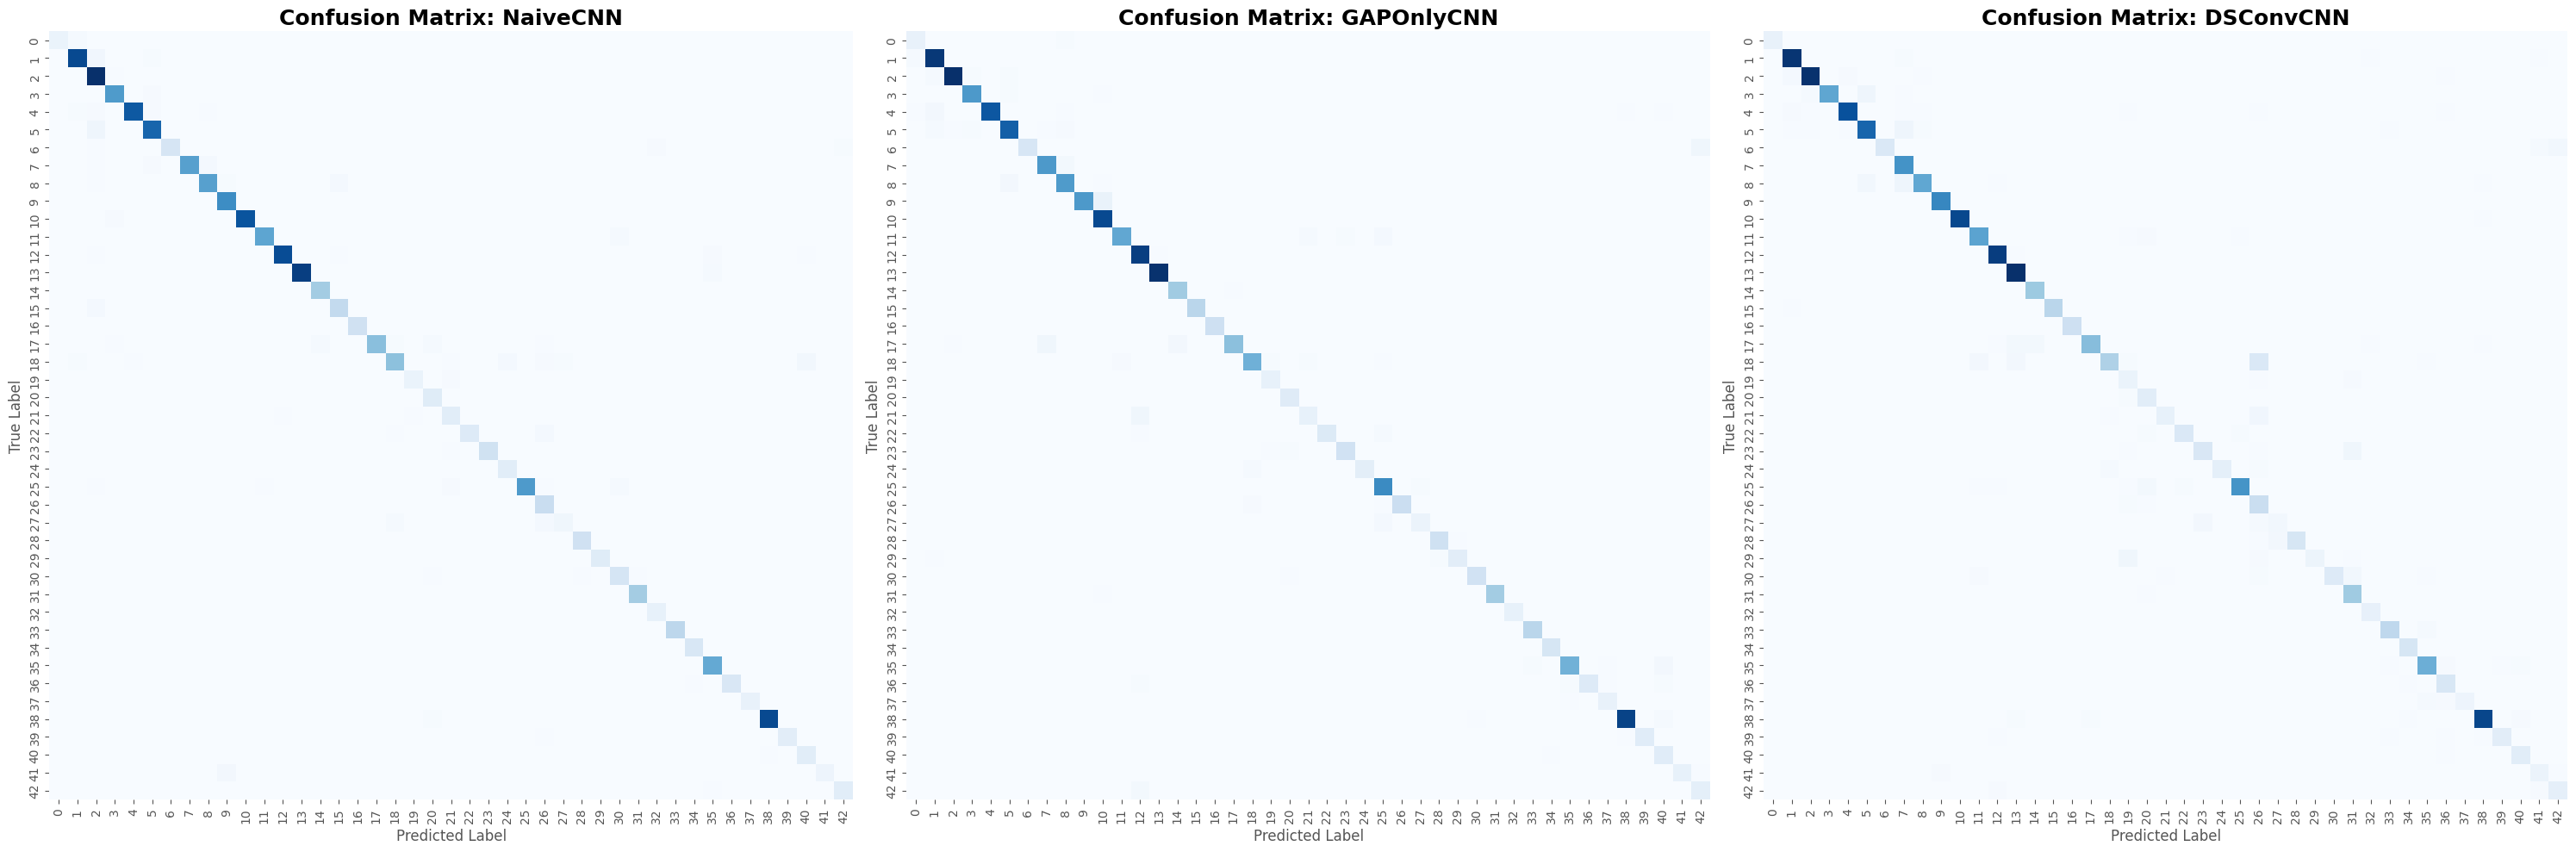

In [23]:
def get_predictions(model, test_loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    return all_labels, all_preds

y_true_n, y_pred_n = get_predictions(model_naive, test_loader_30)
y_true_g, y_pred_g = get_predictions(model_gap, test_loader_48)
y_true_d, y_pred_d = get_predictions(model_ds, test_loader_48)

fig, axes = plt.subplots(1, 3, figsize=(30, 10))
plt.subplots_adjust(wspace=0.2)

results = [
    (y_true_n, y_pred_n, "NaiveCNN"),
    (y_true_g, y_pred_g, "GAPOnlyCNN"),
    (y_true_d, y_pred_d, "DSConvCNN")
]

for i, (y_true, y_pred, title) in enumerate(results):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=False, cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'Confusion Matrix: {title}', fontsize=18, fontweight='bold')
    axes[i].set_xlabel('Predicted Label', fontsize=12)
    axes[i].set_ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.show()

In [24]:
def evaluate_model(model, test_loader, model_name):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    
    correct = 0
    total = 0
    
    print(f"--- Evaluating {model_name} ---")
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    final_acc = 100 * correct / total
    
    print(f"Total Images: {total}")
    print(f"Correct: {correct}")
    print(f"Accuracy: {final_acc:.2f}%\n")
    
    return final_acc

In [25]:
test_results = {}

test_results['NaiveCNN'] = evaluate_model(model_naive, test_loader_30, "NaiveCNN")
test_results['GAPOnlyCNN'] = evaluate_model(model_gap, test_loader_48, "GAPOnlyCNN")
test_results['DSConvCNN'] = evaluate_model(model_ds, test_loader_48, "DSConvCNN")


summary_df = pd.DataFrame(list(test_results.items()), columns=['Model', 'Test Accuracy (%)'])
print("="*30)
print("Test Performance Summary")
print("="*30)
print(summary_df)

--- Evaluating NaiveCNN ---
Total Images: 12630
Correct: 11960
Accuracy: 94.70%

--- Evaluating GAPOnlyCNN ---
Total Images: 12630
Correct: 11900
Accuracy: 94.22%

--- Evaluating DSConvCNN ---
Total Images: 12630
Correct: 11505
Accuracy: 91.09%

Test Performance Summary
        Model  Test Accuracy (%)
0    NaiveCNN          94.695170
1  GAPOnlyCNN          94.220111
2   DSConvCNN          91.092637


In [26]:
def get_model_file_size(model, model_name="model"):
    temp_path = f"temp_{model_name}.pth"
    torch.save(model.state_dict(), temp_path)
    size_mb = os.path.getsize(temp_path) / (1024 * 1024)
    os.remove(temp_path)
    
    print(f"[{model_name}] Original File Size: {size_mb:.2f} MB")
    return size_mb

In [67]:
size_naive = get_model_file_size(model_naive, "NaiveCNN")
size_gap = get_model_file_size(model_gap, "GAPOnlyCNN")
size_ds = get_model_file_size(model_ds, "DSConvCNN")

print("\n" + "="*30)
print("Initial Model Size Comparison")
print("="*30)
print(f"NaiveCNN   : {size_naive:.2f} MB")
print(f"GAPOnlyCNN : {size_gap:.2f} MB")
print(f"DSConvCNN  : {size_ds:.2f} MB")

[NaiveCNN] Original File Size: 6.20 MB
[GAPOnlyCNN] Original File Size: 2.20 MB
[DSConvCNN] Original File Size: 0.79 MB

Initial Model Size Comparison
NaiveCNN   : 6.20 MB
GAPOnlyCNN : 2.20 MB
DSConvCNN  : 0.79 MB


In [ ]:
def visualize_predictions(models_dict, test_loader, device):
    dataiter = iter(test_loader)
    images, labels = next(dataiter)
    
    num_images = 25
    images, labels = images[:num_images], labels[:num_images]

    plt.figure(figsize=(20, 22)) 
    
    for i in range(num_images):
        img = images[i]
        label_idx = labels[i].item()
        gt_name = classes[label_idx]
        
        img_display = img.permute(1, 2, 0).cpu().numpy()
        img_display = np.clip(img_display, 0, 1)

        ax = plt.subplot(5, 5, i + 1)
        ax.imshow(img_display)
        ax.axis('off')

        ax.text(0, 1.26, f"[GT: {gt_name}]", transform=ax.transAxes, 
                fontsize=10, fontweight='bold', color='black')
        
        y_pos = 1.18
        for name, model in models_dict.items():
            model.eval()
            with torch.no_grad():
                input_img = img.unsqueeze(0).to(device)
                if "Naive" in name:
                    input_img = F.interpolate(input_img, size=(30, 30), mode='bilinear', align_corners=False)
                
                output = model(input_img)
                _, pred = torch.max(output, 1)
                pred_idx = pred.item()
                pred_name = classes[pred_idx]
                
                is_correct = (pred_idx == label_idx)
                color = 'blue' if is_correct else 'red'
                mark = 'O' if is_correct else 'X'
                
                ax.text(0, y_pos, f"{mark} {name}: {pred_name}", transform=ax.transAxes, 
                        fontsize=9, color=color)
                y_pos -= 0.08

    plt.subplots_adjust(hspace=0.35, wspace=0.3, top=0.95, bottom=0.05)
    plt.show()

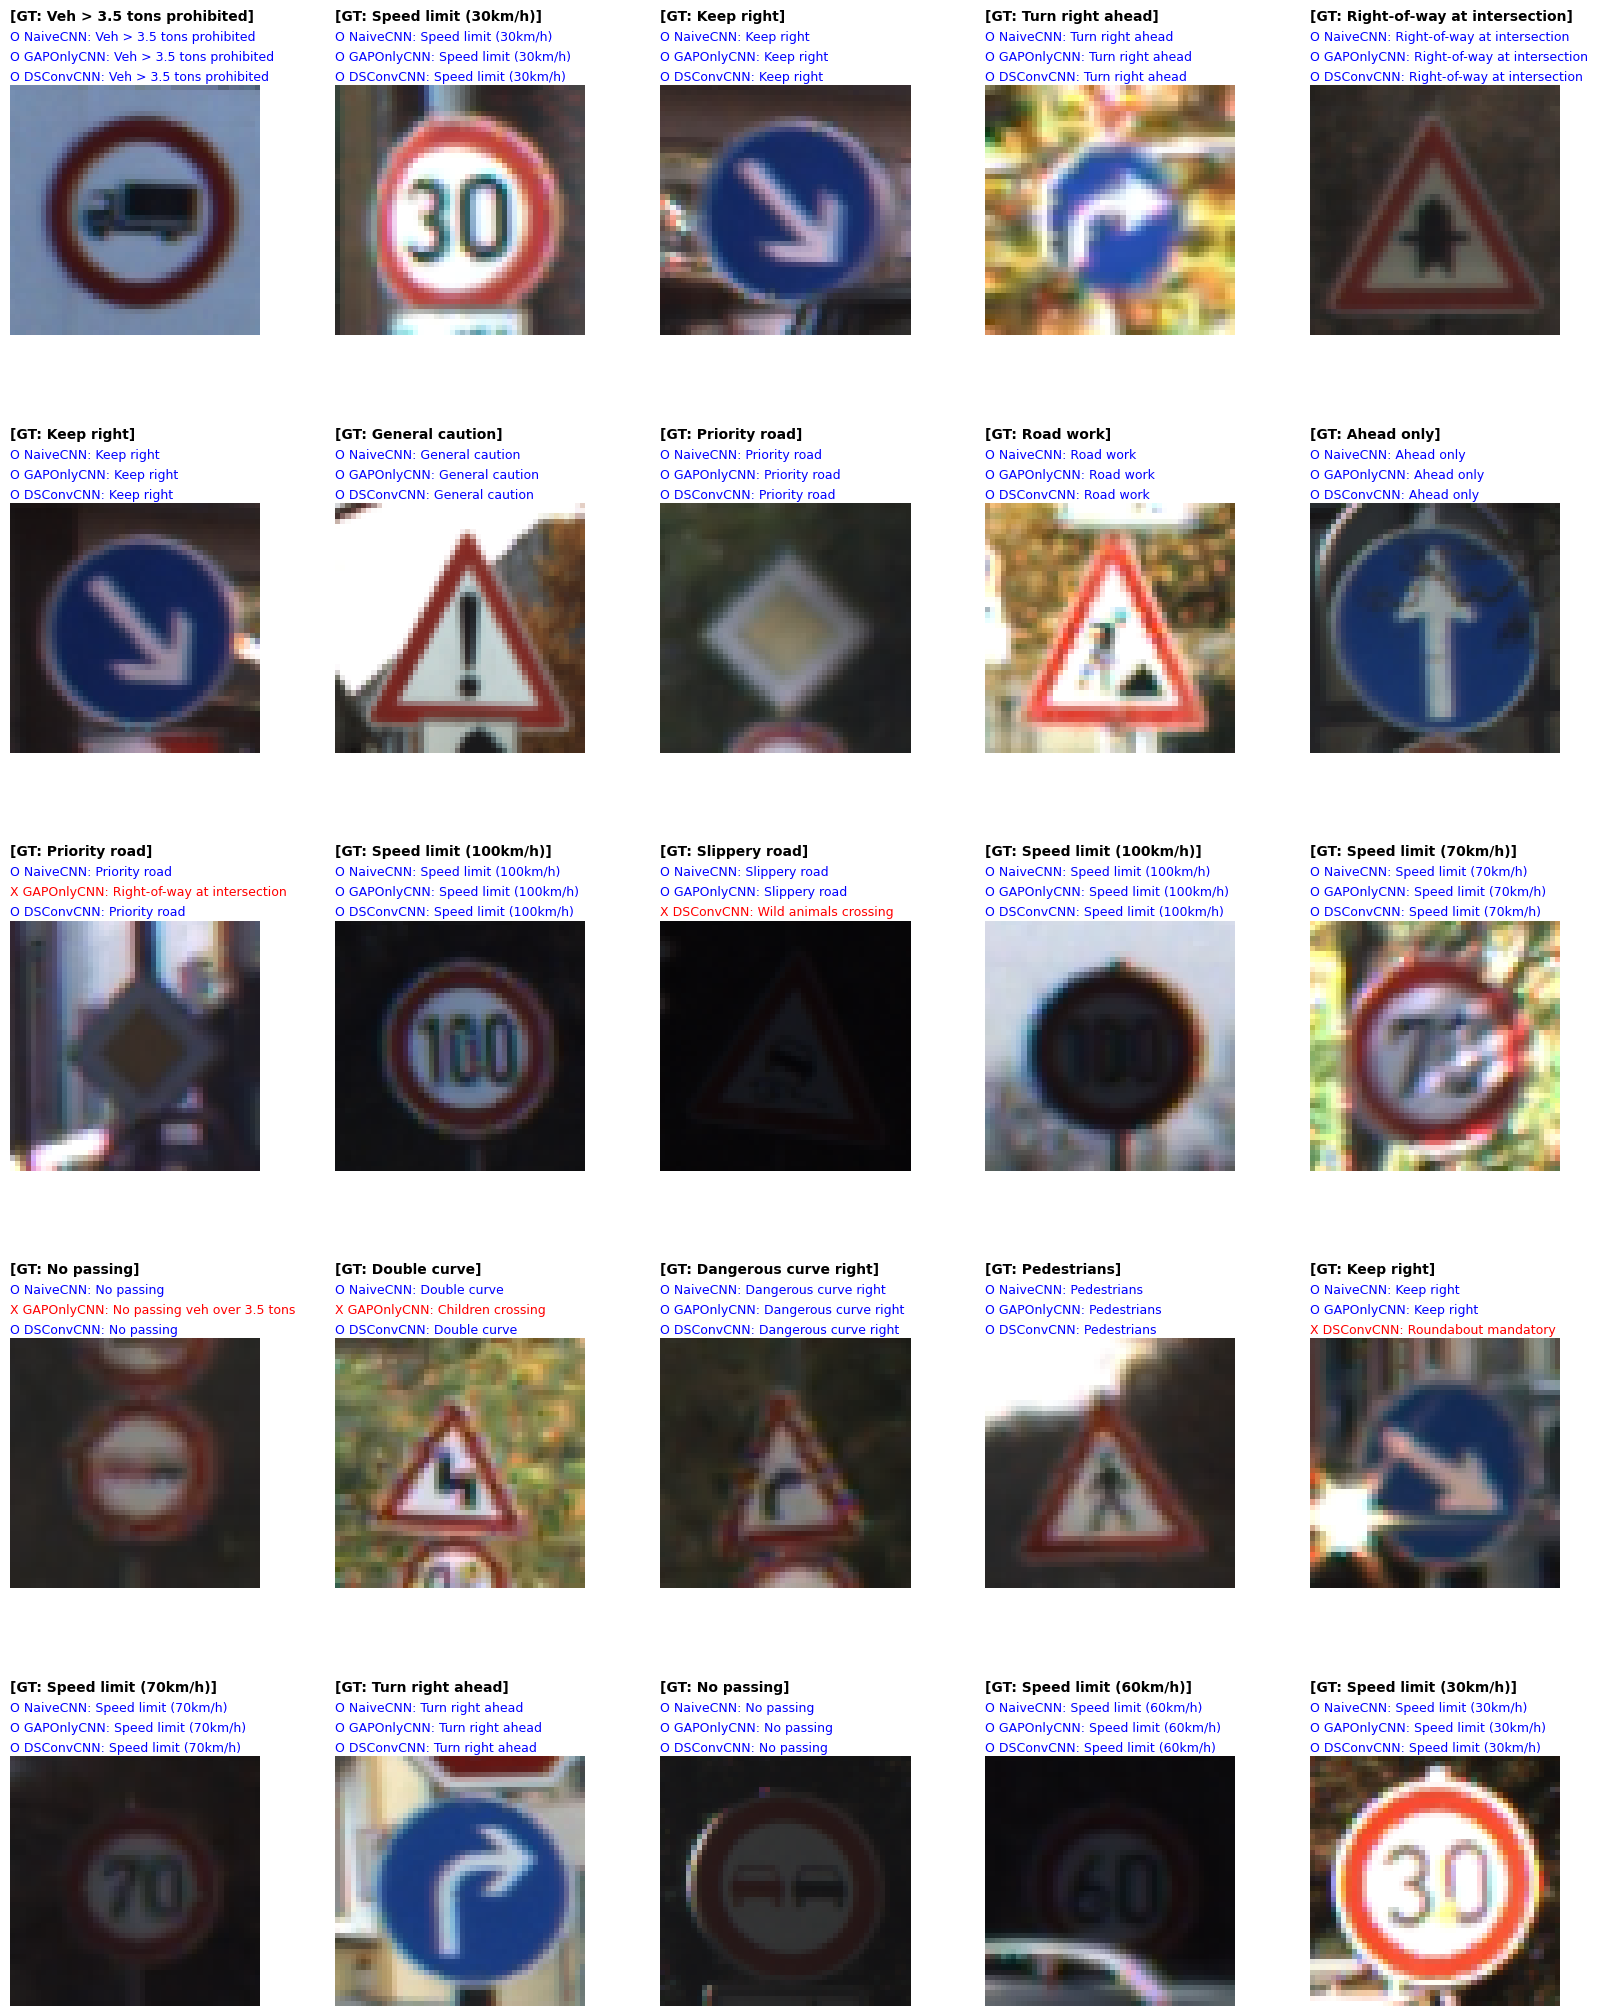

In [71]:
models = {
    "NaiveCNN": model_naive,
    "GAPOnlyCNN": model_gap,
    "DSConvCNN": model_ds
}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

visualize_predictions(models, test_loader_48, device)